<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/HCF_vs_Paper_Fiber_GN_GGN_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hyperbolic GN/GGN 기반 논문 광섬유 vs HCF GSNR·Capacity 비교

이 Colab 노트북은 `tesi(9).pdf` Appendix A의 **GN-model hyperbolic-coordinate 적분 구조**를 Python으로 옮겨, 논문 광섬유와 사용자가 첨부한 HCF 조건을 비교합니다. 그래프 값을 직접 입력하지 않고 다음 순서로 계산합니다.

1. WDM 직사각형(Nyquist) 스펙트럼 생성
2. Hyperbolic 좌표에서 FWM 효율 적분 → 채널별 단일-span NLI 계수 $\eta_i$
3. EDFA ASE, 누적 NLI, XT, transceiver noise 계산
4. $GSNR_i=P_i/(P_{ASE,i}+P_{NLI,i}+P_{XT,i}+P_{TRX,i})$
5. $C=\sum_i 2R_s\log_2(1+GSNR_i/\Gamma)$

> **중요:** 첨부 표의 $\gamma_X=-80$ dB/km는 Kerr 비선형계수 $\gamma$와 단위가 다릅니다. 이 노트북에서는 이를 누적 XT 계수로 사용합니다. HCF의 Kerr $\gamma$는 표에 없으므로 $A_{eff}$와 공기 코어의 $n_2$로 계산합니다. HCF가 진공 상태이거나 측정된 $\gamma$가 있다면 아래 설정 셀의 `N2_HCF_M2_PER_W` 또는 `GAMMA_HCF_OVERRIDE`를 바꾸십시오.

> 입력 표가 상수 $\alpha$와 $D$만 제공하므로, 이 조건에서 GGN의 주파수/공간 의존 항은 사라지고 **GGN은 GN의 상수-파라미터 극한과 동일**합니다. ISRS 또는 파장별 손실을 비교하려면 $\alpha(f,z)$와 $D(f)$ 데이터가 추가로 필요합니다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=4, suppress=True)

# Physical constants
C_LIGHT = 299_792_458.0       # m/s
H_PLANCK = 6.62607015e-34     # J*s

# ------------------------------------------------------------------
# User-editable system conditions (photo table + explicit assumptions)
# ------------------------------------------------------------------
LAMBDA_C_NM = 1550.0
TOTAL_BANDWIDTH_THz = 4.3
RS_GBAUD = 100.0
CHANNEL_SPACING_GHz = 112.5
NF_DB = 4.5
FIFO_LOSS_DB = 2 * 0.3
SPAN_LENGTH_KM = 80.0          # not specified in the photo; editable assumption
TRX_SNR_DB = 20.0              # editable transceiver ceiling
SNR_GAP_DB = 0.0               # 0 dB = ideal Shannon capacity
NLI_COHERENCE_EXPONENT = 0.05  # eta_N ~= eta_1 * Nspan^(1+epsilon_NLI)

# PFE screening parameters from the photo
PFE_MARGIN = 0.10
ETA_E0 = np.mean([2.0, 3.1]) / 100.0
CABLE_R_OHM_PER_KM = 1.0
V_PFE_KV = 18.0
N_SPATIAL_PATHS = 1            # change to total simultaneously powered paths
ENFORCE_PFE_SCREENING = True

# HCF Kerr gamma is not listed in the photo. Default: atmospheric-air n2.
N2_HCF_M2_PER_W = 3.0e-23
GAMMA_HCF_OVERRIDE = None       # e.g. 5e-4 [1/W/km], or None to derive

# Numerical integration resolution. Increase for convergence checking.
N_V1 = 300
N_V2 = 320

lambda_c_m = LAMBDA_C_NM * 1e-9
Rs_Hz = RS_GBAUD * 1e9
spacing_Hz = CHANNEL_SPACING_GHz * 1e9
B_available_Hz = TOTAL_BANDWIDTH_THz * 1e12
Nch = int(np.floor((B_available_Hz - Rs_Hz) / spacing_Hz)) + 1
channel_centers_Hz = (np.arange(Nch) - Nch // 2) * spacing_Hz
occupied_B_Hz = np.ptp(channel_centers_Hz) + Rs_Hz

print(f'Nch = {Nch}, occupied bandwidth = {occupied_B_Hz/1e12:.4f} THz')
print(f'Common system: {RS_GBAUD:.1f} GBaud, {CHANNEL_SPACING_GHz:.1f} GHz spacing, NF={NF_DB:.1f} dB')

Nch = 38, occupied bandwidth = 4.2625 THz
Common system: 100.0 GBaud, 112.5 GHz spacing, NF=4.5 dB


## 1. 광섬유 조건

- **Paper fibre:** 논문 Table 6.4의 SMF-28 ULL 조건 $\alpha=0.16$ dB/km, $D=18.1$ ps/(nm·km), $\gamma=1.0088$ W⁻¹km⁻¹
- **HCF (provided table):** $D=-21$ ps/(nm·km), $A_{eff}=110$ μm², $\alpha=0.15$ dB/km, $\gamma_X=-80$ dB/km

HCF Kerr 계수는 다음 식으로 계산합니다.

$$\gamma_{HCF}=\frac{2\pi n_{2,core}}{\lambda A_{eff}}.$$

공기압·가스종·진공도에 따라 $n_2$가 달라지므로 HCF 결과의 주요 민감도 변수입니다.

In [2]:
@dataclass(frozen=True)
class Fiber:
    name: str
    alpha_db_per_km: float
    D_ps_per_nm_km: float
    gamma_W_inv_km: float
    xt_db_per_km: float | None = None

def gamma_from_n2(n2_m2_per_W, wavelength_m, Aeff_um2):
    Aeff_m2 = Aeff_um2 * 1e-12
    return 2 * np.pi * n2_m2_per_W / (wavelength_m * Aeff_m2) * 1e3

gamma_hcf = (GAMMA_HCF_OVERRIDE if GAMMA_HCF_OVERRIDE is not None
             else gamma_from_n2(N2_HCF_M2_PER_W, lambda_c_m, 110.0))

paper_fiber = Fiber(
    name='Paper fibre (SMF-28 ULL)',
    alpha_db_per_km=0.16,
    D_ps_per_nm_km=18.1,
    gamma_W_inv_km=1.0088,
    xt_db_per_km=None,
)
hcf = Fiber(
    name='HCF (provided table)',
    alpha_db_per_km=0.15,
    D_ps_per_nm_km=-21.0,
    gamma_W_inv_km=gamma_hcf,
    xt_db_per_km=-80.0,
)
fibers = [paper_fiber, hcf]

for f in fibers:
    print(f'{f.name:28s} alpha={f.alpha_db_per_km:.3f} dB/km, '          f'D={f.D_ps_per_nm_km:+.2f} ps/(nm km), gamma={f.gamma_W_inv_km:.4g} 1/(W km), '          f'XT={f.xt_db_per_km}')

Paper fibre (SMF-28 ULL)     alpha=0.160 dB/km, D=+18.10 ps/(nm km), gamma=1.009 1/(W km), XT=None
HCF (provided table)         alpha=0.150 dB/km, D=-21.00 ps/(nm km), gamma=0.001106 1/(W km), XT=-80.0


## 2. Hyperbolic-coordinate GN 적분

Appendix A의 좌표변환을 사용합니다. CUT 주파수를 0으로 이동하면

$$f_1=\nu_1 e^{\nu_2},\qquad f_2=\nu_1e^{-\nu_2},\qquad |J|=2|\nu_1|.$$

네 개 사분면의 WDM PSD 곱을 합산하고 FWM 효율

$$\rho=\frac{1-e^{(-\alpha+j\Delta\beta)L_s}}{\alpha-j\Delta\beta},\qquad
\Delta\beta=4\pi^2\beta_2\nu_1^2$$

을 적분합니다. 단일-span 결과 $\eta_{1,i}$를 구한 뒤 다중 span에는 $N_s^{1+\epsilon_{NLI}}$ 누적법을 사용합니다. 이는 매우 빠르게 진동하는 coherent accumulation factor를 거친 격자로 직접 적분하면서 발생하는 aliasing을 피하기 위한 실용적 GN 근사입니다.

In [3]:
def beta2_from_D(D_ps_per_nm_km, wavelength_m=lambda_c_m):
    # D [ps/(nm km)] -> D*1e-6 [s/m^2]
    D_SI = D_ps_per_nm_km * 1e-6
    return -D_SI * wavelength_m**2 / (2 * np.pi * C_LIGHT)  # s^2/m

def rectangular_wdm_psd(freq_Hz, centers_Hz, pch_W=1.0):
    # Fast membership test for equal-spaced rectangular channels.
    freq_Hz = np.asarray(freq_Hz)
    first = centers_Hz[0]
    idx = np.rint((freq_Hz - first) / spacing_Hz).astype(np.int64)
    valid = (idx >= 0) & (idx < len(centers_Hz))
    idx_clip = np.clip(idx, 0, len(centers_Hz) - 1)
    valid &= np.abs(freq_Hz - centers_Hz[idx_clip]) <= Rs_Hz / 2
    return valid.astype(float) * (pch_W / Rs_Hz)

def gn_hyperbolic_eta_per_channel(fiber, span_length_km=SPAN_LENGTH_KM,
                                    n_v1=N_V1, n_v2=N_V2):
    beta2 = beta2_from_D(fiber.D_ps_per_nm_km)
    gamma = fiber.gamma_W_inv_km / 1e3        # 1/(W m)
    alpha_power = fiber.alpha_db_per_km / 4.343 / 1e3  # 1/m
    Ls_m = span_length_km * 1e3
    eta = np.zeros(Nch)

    for k, cut_Hz in enumerate(channel_centers_Hz):
        centers_rel = channel_centers_Hz - cut_Hz
        max_abs = max(abs(centers_rel[0] - Rs_Hz/2),
                      abs(centers_rel[-1] + Rs_Hz/2))

        # Log grid resolves the sharp FWM peak near nu1=0.
        v1_min = max(1e5, max_abs * 1e-9)
        v1 = np.geomspace(v1_min, max_abs, n_v1)
        v2_max = np.log(np.maximum(max_abs / v1, 1.0))
        u = np.linspace(0.0, 1.0, n_v2)
        v2 = v2_max[:, None] * u[None, :]

        a = v1[:, None] * np.exp(v2)
        b = v1[:, None] * np.exp(-v2)
        f_cosh = 2 * v1[:, None] * np.cosh(v2)
        f_sinh = 2 * v1[:, None] * np.sinh(v2)

        Gp1 = rectangular_wdm_psd(a, centers_rel)
        Gp2 = rectangular_wdm_psd(b, centers_rel)
        Gm1 = rectangular_wdm_psd(-a, centers_rel)
        Gm2 = rectangular_wdm_psd(-b, centers_rel)

        # Four hyperbolic quadrants, equivalent to Appendix A Eq. (2.4).
        psd_product = (
            Gp1 * Gp2 * rectangular_wdm_psd(f_cosh, centers_rel)
            + Gp1 * Gm2 * rectangular_wdm_psd(f_sinh, centers_rel)
            + Gm1 * Gp2 * rectangular_wdm_psd(-f_sinh, centers_rel)
            + Gm1 * Gm2 * rectangular_wdm_psd(-f_cosh, centers_rel)
        )
        inner_integral = np.trapezoid(psd_product, v2, axis=1)

        delta_beta = 4 * np.pi**2 * beta2 * v1**2
        rho2 = np.abs((1 - np.exp((-alpha_power + 1j*delta_beta) * Ls_m))
                      / (alpha_power - 1j*delta_beta))**2
        outer_integrand = rho2 * inner_integral * (2 * v1)
        Gnli_center_W_per_Hz = (32/27) * gamma**2 * np.trapezoid(outer_integrand, v1)

        # P_NLI ~= G_NLI(f_CUT)*Rs = eta*Pch^3; integral used Pch=1 W.
        eta[k] = Gnli_center_W_per_Hz * Rs_Hz

    return eta

eta_gn = {f.name: gn_hyperbolic_eta_per_channel(f) for f in fibers}
# With constant alpha and D, the generalized model reduces to this GN result.
eta_ggn_constant_limit = {name: values.copy() for name, values in eta_gn.items()}

for f in fibers:
    x = eta_gn[f.name]
    print(f'{f.name:28s}: center eta={x[Nch//2]:.4g} W^-2, '          f'range=[{x.min():.4g}, {x.max():.4g}] W^-2')

Paper fibre (SMF-28 ULL)    : center eta=117.3 W^-2, range=[88.28, 117.3] W^-2
HCF (provided table)        : center eta=0.000132 W^-2, range=[9.986e-05, 0.000132] W^-2


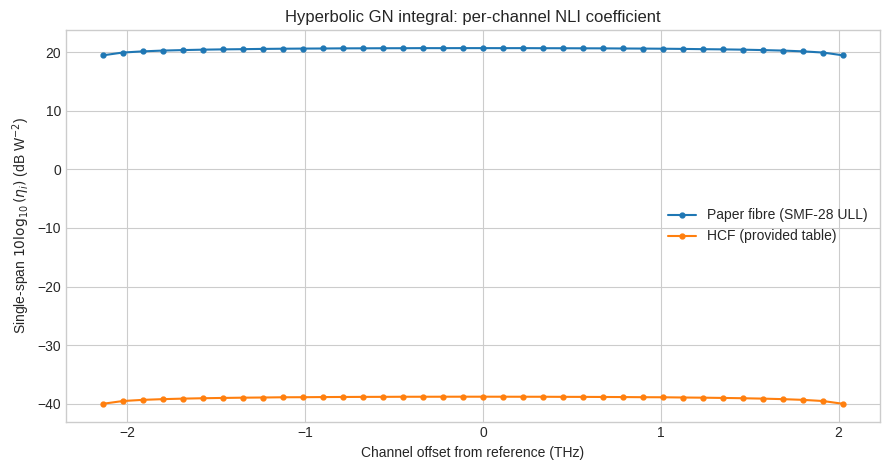

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.8))
freq_THz = channel_centers_Hz / 1e12
for f in fibers:
    ax.plot(freq_THz, 10*np.log10(eta_gn[f.name]), 'o-', ms=3.5, label=f.name)
ax.set_xlabel('Channel offset from reference (THz)')
ax.set_ylabel(r'Single-span $10\log_{10}(\eta_i)$ (dB W$^{-2}$)')
ax.set_title('Hyperbolic GN integral: per-channel NLI coefficient')
ax.legend()
plt.tight_layout()
plt.show()

## 3. ASE·NLI·XT·TRX → GSNR와 Capacity

EDFA가 각 span의 광섬유 손실과 FIFO 0.6 dB를 보상한다고 두고, dual-polarization ASE를

$$P_{ASE,span}=NF\,h\nu(G-1)R_s$$

로 계산합니다. 약한 누적 XT는 $P_{XT}/P_s\approx L\,10^{\gamma_X/10}$로 계산합니다. PFE 한계는 표의 18 kV, 1 Ω/km, 10% margin, 평균 2.55% 변환효율을 이용한 **screening approximation**으로만 적용합니다. 정확한 cable capacity에는 실제 FP/core 수와 repeater 전력배분 모델이 필요합니다.

In [5]:
def pfe_max_pch_dbm(link_length_km, n_spatial_paths=N_SPATIAL_PATHS):
    # Maximum-power-transfer screening: P_load <= V^2/(4 R_line).
    n_spans = int(round(link_length_km / SPAN_LENGTH_KM))
    R_line = CABLE_R_OHM_PER_KM * link_length_km
    P_electrical_load_W = ((1-PFE_MARGIN) * (V_PFE_KV*1e3)**2
                           / (4 * R_line))
    P_optical_sum_W = ETA_E0 * P_electrical_load_W
    Pout_per_amplifier_W = P_optical_sum_W / (n_spans * n_spatial_paths)
    pch_W = Pout_per_amplifier_W / Nch
    return 10*np.log10(pch_W/1e-3)

def gsnr_capacity(fiber, eta1_vector, link_length_km, pch_dbm):
    n_spans_float = link_length_km / SPAN_LENGTH_KM
    if not np.isclose(n_spans_float, round(n_spans_float)):
        raise ValueError('Use link lengths that are integer multiples of SPAN_LENGTH_KM.')
    n_spans = int(round(n_spans_float))

    pch_W = 1e-3 * 10**(np.asarray(pch_dbm)/10)
    span_gain_db = fiber.alpha_db_per_km * SPAN_LENGTH_KM + FIFO_LOSS_DB
    gain_lin = 10**(span_gain_db/10)
    NF_lin = 10**(NF_DB/10)
    nu = C_LIGHT / lambda_c_m
    Pase_span_W = NF_lin * H_PLANCK * nu * (gain_lin - 1) * Rs_Hz
    Pase_W = n_spans * Pase_span_W

    # Broadcast: power axis x channel axis
    P = np.atleast_1d(pch_W)[:, None]
    Pnli_W = (eta1_vector[None, :] * n_spans**(1+NLI_COHERENCE_EXPONENT) * P**3)
    Ptrx_W = P / 10**(TRX_SNR_DB/10)

    if fiber.xt_db_per_km is None:
        Pxt_W = np.zeros_like(P)
    else:
        xt_ratio = link_length_km * 10**(fiber.xt_db_per_km/10)
        Pxt_W = P * xt_ratio

    gsnr = P / (Pase_W + Pnli_W + Ptrx_W + Pxt_W)
    gap = 10**(SNR_GAP_DB/10)
    capacity_bps = np.sum(2 * Rs_Hz * np.log2(1 + gsnr/gap), axis=1)
    return {
        'gsnr': gsnr, 'capacity_bps': capacity_bps, 'Pase_W': Pase_W,
        'Pnli_W': Pnli_W, 'Ptrx_W': Ptrx_W, 'Pxt_W': Pxt_W,
        'n_spans': n_spans,
    }

def feasible_power_grid(link_length_km, pmin=-10.0, pmax=22.0, step=0.2):
    grid = np.arange(pmin, pmax + step/2, step)
    if ENFORCE_PFE_SCREENING:
        grid = grid[grid <= pfe_max_pch_dbm(link_length_km)]
    if grid.size == 0:
        raise RuntimeError('No launch power remains after PFE screening.')
    return grid

Paper fibre (SMF-28 ULL): Popt=1.40 dBm/ch, center GSNR=11.44 dB, C=29.80 Tb/s
HCF (provided table): Popt=20.20 dBm/ch, center GSNR=19.73 dB, C=49.94 Tb/s


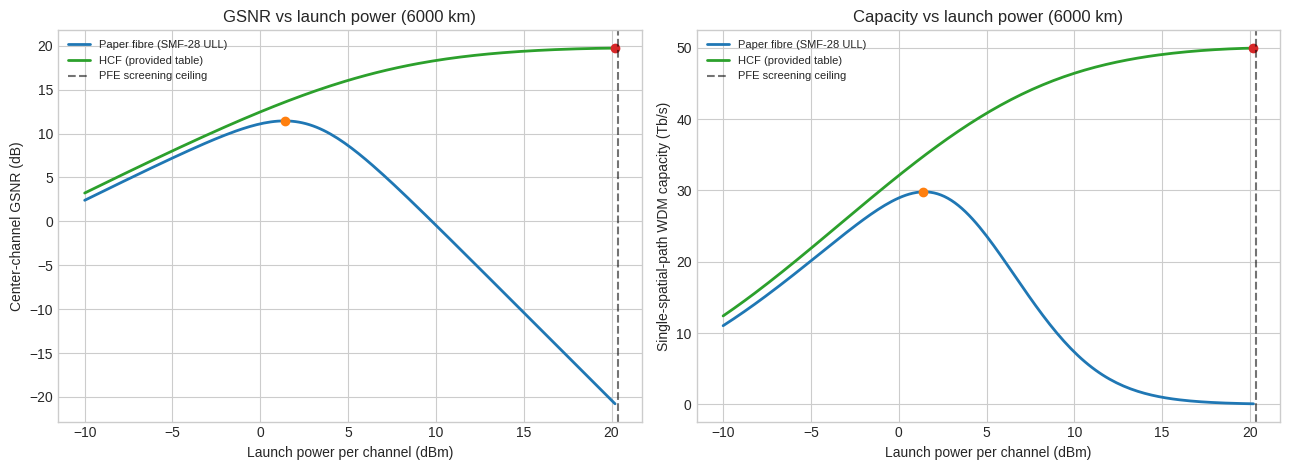

In [6]:
# Launch-power comparison at a representative transoceanic distance.
LINK_KM = 6000.0
power_dbm = feasible_power_grid(LINK_KM, -10, 22, 0.2)
results_power = {f.name: gsnr_capacity(f, eta_gn[f.name], LINK_KM, power_dbm)
                 for f in fibers}
center_idx = Nch // 2

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for f in fibers:
    r = results_power[f.name]
    g_center_db = 10*np.log10(r['gsnr'][:, center_idx])
    capacity_tbps = r['capacity_bps']/1e12
    axes[0].plot(power_dbm, g_center_db, lw=2, label=f.name)
    axes[1].plot(power_dbm, capacity_tbps, lw=2, label=f.name)
    j = np.argmax(capacity_tbps)
    axes[0].plot(power_dbm[j], g_center_db[j], 'o')
    axes[1].plot(power_dbm[j], capacity_tbps[j], 'o')
    print(f'{f.name}: Popt={power_dbm[j]:.2f} dBm/ch, '          f'center GSNR={g_center_db[j]:.2f} dB, C={capacity_tbps[j]:.2f} Tb/s')

pfe_ceiling = pfe_max_pch_dbm(LINK_KM)
for ax in axes:
    ax.axvline(pfe_ceiling, color='k', ls='--', alpha=0.55, label='PFE screening ceiling')
    ax.set_xlabel('Launch power per channel (dBm)')
axes[0].set_ylabel('Center-channel GSNR (dB)')
axes[1].set_ylabel('Single-spatial-path WDM capacity (Tb/s)')
axes[0].set_title(f'GSNR vs launch power ({LINK_KM:.0f} km)')
axes[1].set_title(f'Capacity vs launch power ({LINK_KM:.0f} km)')
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[0].legend(by_label.values(), by_label.keys(), fontsize=8)
axes[1].legend(by_label.values(), by_label.keys(), fontsize=8)
plt.tight_layout()
plt.show()

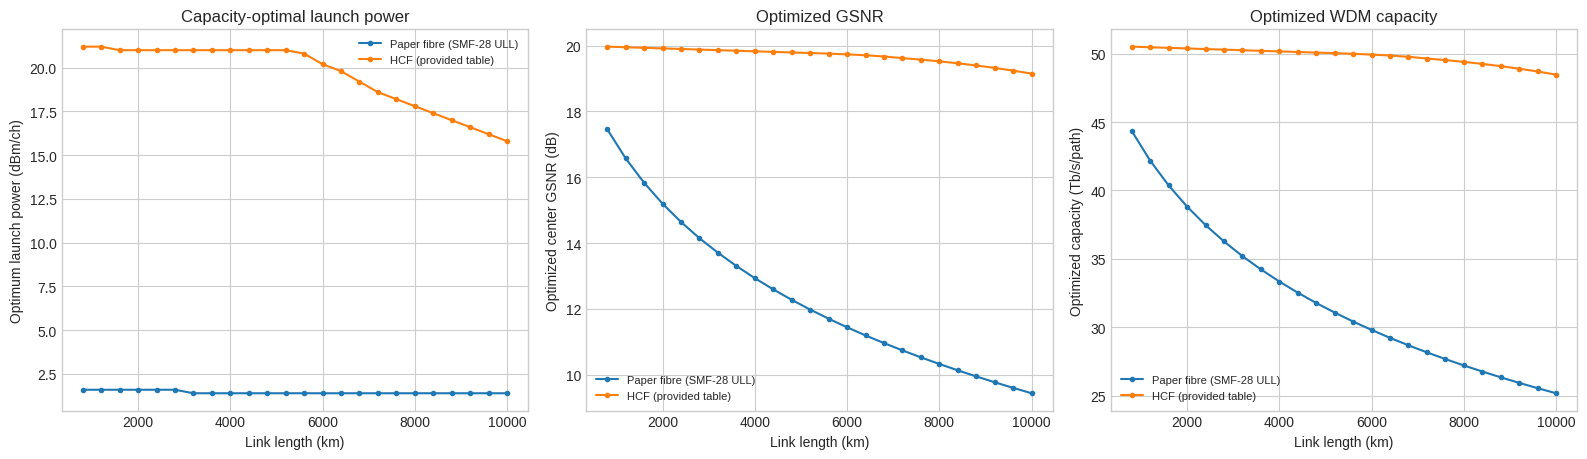

In [7]:
# Distance sweep: optimize launch power independently at every distance.
distance_km = np.arange(800.0, 10000.1, 400.0)  # multiples of 80 km
distance_summary = {}

for f in fibers:
    popt, gopt, copt = [], [], []
    for L in distance_km:
        grid = feasible_power_grid(L, -10, 22, 0.2)
        r = gsnr_capacity(f, eta_gn[f.name], L, grid)
        j = np.argmax(r['capacity_bps'])
        popt.append(grid[j])
        gopt.append(10*np.log10(r['gsnr'][j, center_idx]))
        copt.append(r['capacity_bps'][j]/1e12)
    distance_summary[f.name] = {
        'popt_dbm': np.array(popt), 'gsnr_db': np.array(gopt),
        'capacity_tbps': np.array(copt),
    }

fig, axes = plt.subplots(1, 3, figsize=(16, 4.7))
for f in fibers:
    s = distance_summary[f.name]
    axes[0].plot(distance_km, s['popt_dbm'], 'o-', ms=3, label=f.name)
    axes[1].plot(distance_km, s['gsnr_db'], 'o-', ms=3, label=f.name)
    axes[2].plot(distance_km, s['capacity_tbps'], 'o-', ms=3, label=f.name)
axes[0].set_ylabel('Optimum launch power (dBm/ch)')
axes[1].set_ylabel('Optimized center GSNR (dB)')
axes[2].set_ylabel('Optimized capacity (Tb/s/path)')
for ax in axes:
    ax.set_xlabel('Link length (km)')
    ax.legend(fontsize=8)
axes[0].set_title('Capacity-optimal launch power')
axes[1].set_title('Optimized GSNR')
axes[2].set_title('Optimized WDM capacity')
plt.tight_layout()
plt.show()

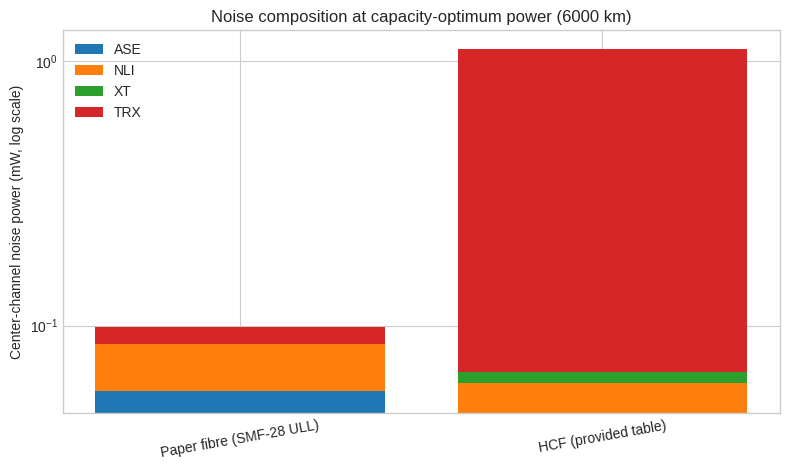

PFE screening ceiling at 6000 km and 1 path(s): 20.36 dBm/ch


In [8]:
# Noise composition at each fibre's capacity-optimum point at LINK_KM.
labels_noise = ['ASE', 'NLI', 'XT', 'TRX']
noise_data = []
for f in fibers:
    r = results_power[f.name]
    j = np.argmax(r['capacity_bps'])
    vals = [
        float(r['Pase_W']),
        float(r['Pnli_W'][j, center_idx]),
        float(np.broadcast_to(r['Pxt_W'], r['Pnli_W'].shape)[j, center_idx]),
        float(r['Ptrx_W'][j, 0]),
    ]
    noise_data.append(vals)

x = np.arange(len(fibers))
bottom = np.zeros(len(fibers))
fig, ax = plt.subplots(figsize=(8, 4.8))
for m, lab in enumerate(labels_noise):
    values = np.array([row[m] for row in noise_data]) * 1e3
    ax.bar(x, values, bottom=bottom, label=lab)
    bottom += values
ax.set_yscale('log')
ax.set_xticks(x, [f.name for f in fibers], rotation=10)
ax.set_ylabel('Center-channel noise power (mW, log scale)')
ax.set_title(f'Noise composition at capacity-optimum power ({LINK_KM:.0f} km)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'PFE screening ceiling at {LINK_KM:.0f} km and {N_SPATIAL_PATHS} path(s): '      f'{pfe_max_pch_dbm(LINK_KM):.2f} dBm/ch')

## 4. 결과 해석과 재현 시 주의사항

- HCF의 공기 코어 $n_2$ 가정 때문에 Kerr $\gamma$와 $\eta$가 논문 광섬유보다 매우 작게 계산됩니다. 따라서 HCF는 NLI보다 ASE·TRX·PFE 제한을 먼저 받습니다.
- 논문 광섬유는 launch power가 증가하면 $P_{NLI}\propto P^3$가 빠르게 커져 명확한 optimum launch power가 나타납니다.
- HCF의 $\gamma_X=-80$ dB/km는 약한 선형 누적 XT 항입니다. 이 값이 실제로 IMI 또는 다른 정의라면 해당 논문의 정의에 맞춰 `Pxt_W` 식을 교체해야 합니다.
- 입력값이 상수 $\alpha,D$이므로 GN과 GGN 결과는 동일합니다. C+L/UWB에서 GGN 효과를 보려면 파장별 attenuation/dispersion과 ISRS Raman 계수가 필요합니다.
- `N_SPATIAL_PATHS`를 실제 cable의 동시 증폭 경로 수로 바꾸면 PFE ceiling과 cable total capacity를 더 현실적으로 비교할 수 있습니다. 총 cable capacity는 현재 출력의 `capacity × N_SPATIAL_PATHS`이지만, PFE ceiling도 함께 감소하므로 반드시 재실행해야 합니다.
- Hyperbolic 적분 수렴성은 `N_V1`, `N_V2`를 1.5~2배 증가시켜 $\eta_i$ 변화가 충분히 작은지 확인하십시오.

### 직접 수정할 핵심 셀

1. `SPAN_LENGTH_KM`, `TRX_SNR_DB`, `N_SPATIAL_PATHS`
2. 측정된 HCF Kerr 계수가 있으면 `GAMMA_HCF_OVERRIDE`
3. 실제 구현손실을 포함하려면 `SNR_GAP_DB`
4. PFE 모델을 사용하지 않는 순수 광학 비교는 `ENFORCE_PFE_SCREENING=False`